# Imports

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import tables
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import tqdm.notebook as tqdm
from typing import Callable
import torchmetrics
import PIL
from transformers import AutoTokenizer
import seaborn as sns

# Exploratory data analysis

In [2]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-VL-Embedding-2B")

## Dataset

В качестве датасета я использовал набор данных с Авито, загруженный на [Kaggle](https://www.kaggle.com/competitions/avito-demand-prediction). В нем 1.5 млн объявлений с авито, содержащих в том числе и картинки

In [3]:
df = pd.read_csv("./data/avito_train.csv")

In [5]:
df.columns

Index(['item_id', 'user_id', 'region', 'city', 'parent_category_name',
       'category_name', 'param_1', 'param_2', 'param_3', 'title',
       'description', 'price', 'item_seq_number', 'activation_date',
       'user_type', 'image', 'image_top_1', 'deal_probability'],
      dtype='object')

Мы предполагаем, что модель работает в реальном времени после создания объявления для автоматического определения категории, поэтому такие фичи в датасете как image_top_1, регион, город, тип пользователя и так далее, не помогут этому; основной источник данных в этом случае -- заголовок, описание и изображение. Дополнительные параметры я также убрал, так как они больше похожи на сильно вложенные подкатегории или систему тегов.

В итоге я решил оставить только основную категорию, подкатегорию, заголовок, описание и изображение

In [7]:
df = df[["parent_category_name", "category_name", "title", "description", "image"]]

In [8]:
df["image"] += ".jpg"

/tmp/ipykernel_53423/1663874741.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["image"] += ".jpg"


## Preparing and cleaning

Датасет на самом деле просто огромный -- ~80 Гб, из которых половина -- картинки, поэтому на странице датасета картинки разделены на 5 архивов, я загрузил только один, так как для моего решения данных нужно очень немного и даже 1/5 датасета хватит с головой, однако теперь нужно оставить в таблице только те объявления, картинки которых я скачал, а также объявления без изображений

In [9]:
images = {
    p.name for p in Path('./data/avito_img').iterdir() if p.is_file()
}

In [10]:
df = df[df["image"].isin(images) | df["image"].isnull()]

In [11]:
df["image"] = "./data/avito_img/" + df["image"]

Здесь я объединяю заголовок и описание объявления в один текст, затем пишу промпт для вычисления эмбеддингов

In [12]:
def make_text(item):
    return f"Title: {item["title"]}\n\n{'Description: ' + str(item["description"]) if item["description"] is not None else ''}"

In [13]:
df["text"] = df.apply(make_text, axis=1)

In [24]:
df["parent_category_name"].value_counts()

parent_category_name
Личные вещи            144657
Недвижимость            69780
Для дома и дачи         45493
Бытовая электроника     41031
Услуги                  28232
Транспорт               20107
Хобби и отдых           19702
Животные                17025
Для бизнеса              4729
Name: count, dtype: int64

Распределение классов сильно не сбалансированно, и, как показывает практика, в этом случае наиболее выгодно обучать голову с весами классов, обратно пропорциональными их частотам, будем иметь в виду

<Axes: xlabel='parent_category_name', ylabel='count'>

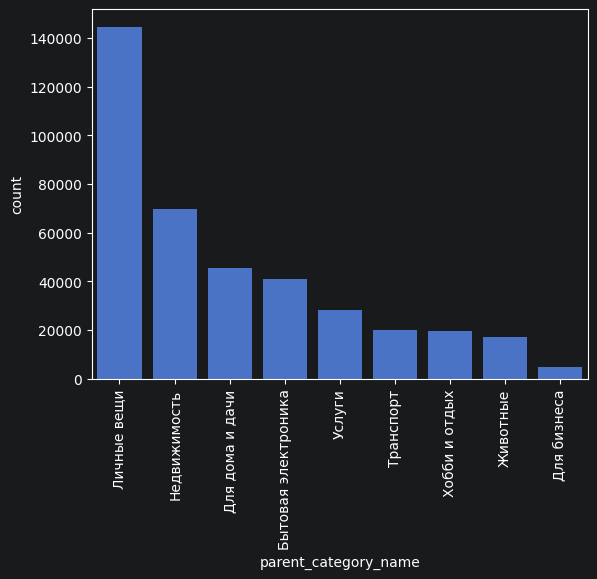

In [26]:
plt.xticks(rotation=90)
sns.barplot(df["parent_category_name"].value_counts())

<Axes: xlabel='category_name', ylabel='count'>

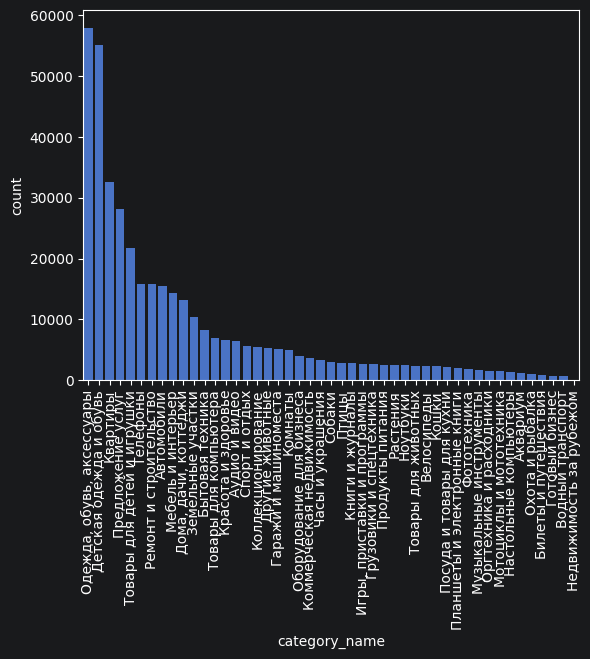

In [27]:
plt.xticks(rotation=90)
sns.barplot(df["category_name"].value_counts())

После всего этого я хочу посмотреть на распределение длин текстов, а также посмотреть некоторые квантили этого распределения

В итоге получается, что около 85% датасета находится в пределах длины 128 токенов, значит я могу себе позволить длинные тексты выкинуть и сэкономить время, и при этом не потерять много данных и разнообразия

In [38]:
df["text_len"] = df["text"].apply(lambda x: len(tokenizer.encode(x)))

<Axes: >

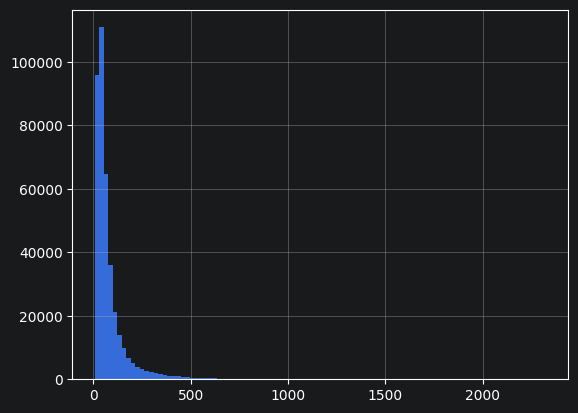

In [39]:
df["text_len"].hist(bins=100)

In [40]:
df["text_len"].quantile(0.85)

129.0

In [41]:
df = df[df["text_len"] <= 128]

Здесь я кодирую классы с помощью LabelEncoder из scikit-learn, так как он сохраняет в удобном формате закодированные классы, а factorize в pandas придумали вообще не для этого

In [42]:
cat_le = LabelEncoder()
subcat_le = LabelEncoder()

In [43]:
df["parent_category_name"] = cat_le.fit_transform(df["parent_category_name"])
df["category_name"] = subcat_le.fit_transform(df["category_name"])

In [44]:
df = df.drop(["title", "description"], axis=1)

Обычно я бы так не делал, но считать эмбеддинги буквально 200+ часов на своем компе не особо хочется, поэтому я возьму для обучения 5% от датасета -- случайных, естественно

(эмбеддинги все равно считались 11 часов)

In [45]:
dataset_frac = 0.05

In [46]:
rng = np.random.default_rng()

In [47]:
idx = rng.choice(np.arange(len(df)), size=int(len(df) * dataset_frac), replace=False)
df = df.iloc[idx]

In [48]:
df

,parent_category_name,category_name,image,text,text_len
1115520,5,13,NaN,Title: Участок 10 сот. (ИЖС)\n\nDescription: П...,33
1013277,4,29,./data/avito_img/859b518f2618b59876adf12dee146...,Title: Кофта\n\nDescription: nan,10
1237700,3,1,./data/avito_img/70927c39629ae72e8727f3c754f45...,Title: Золотые рыбки\n\nDescription: породам з...,25
857767,4,29,NaN,Title: Костюм мужской от пониженных температур...,50
92332,8,24,./data/avito_img/a1f7b1e16136eafc6cbc41a1bd661...,Title: Продам баян\n\nDescription: Б/ у,15
...,...,...,...,...,...
665472,2,4,./data/avito_img/3b2ba4b27f8f86dcdd2e38d578036...,Title: Утюжки/щипцы для волос\n\nDescription: ...,37
1237333,6,23,./data/avito_img/9876ca08cc15e1ca882d03740e905...,Title: Продам альфочку)\n\nDescription: Продам...,124
90281,4,10,./data/avito_img/6aecc5ec9a94b1bb333f23edce44f...,Title: Ползунки\n\nDescription: Продаю ползунк...,54
829523,0,41,./data/avito_img/0f27d16d37b9bf739f7e982b294d3...,Title: Бампер\n\nDescription: Силикон новый но...,45


In [50]:
prompt = f"You will get an advertisement with title (in Russian), optional description and optional image. You task is to define a category and subcategory of this advertisement. You can choose category from this list:\n- {'\n- '.join(cat_le.classes_)}\nThe subcategory is one of the following:\n- {'\n- '.join(subcat_le.classes_)}"

В общем самое лучшее и эффективное по всем показателям решение данной задачи -- transfer learning: считаем эмбеддинги объявлений, обучаем маленькую модельку для классификации. Я решил заюзать мультимодальную модель квена для эмбеддингов, так как она идеально подходит для этой задачи -- мы хотим учитывать информацию как из текста, так и из картинок, и для удобства использую обертку в виде Sentence Transformer

In [51]:
embedder = SentenceTransformer("Qwen/Qwen3-VL-Embedding-2B")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Default prompt name is set to 'default'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.


Для сохранения эмбеддингов я использовал библиотеку tables, которая позволяет хранить датасет на диске и брать только нужные мне индексы сразу из файла. В него я сохраняю метки и готовые эмбеддинги

In [ ]:
file_batch_size = 8

In [26]:
filters = tables.Filters(3, "blosc:lz4")
with tables.open_file("./data/embeddings_avito.hdf5", "w") as file, torch.inference_mode():
    embeddings = file.create_carray(file.root, "embedding", tables.Float32Atom(), shape=(len(df), 2048), filters=filters)
    cat_labels = file.create_carray(file.root, "category_label", tables.Int16Atom(), shape=(len(df),), filters=filters)
    subcat_labels = file.create_carray(file.root, "subcategory_label", tables.Int16Atom(), shape=(len(df),), filters=filters)


    for i in tqdm.trange(0, len(df), file_batch_size):
        texts = [
            {"text": row["text"], "image": row["image"]} if isinstance(row["image"], str) else row["text"]
            for _, row in df.iloc[i:i + file_batch_size].iterrows()
        ]
        embedding = embedder.encode(texts, prompt=prompt)

        embeddings[i:i + file_batch_size] = embedding
        cat_labels[i:i + file_batch_size] = df["parent_category_name"][i:i + file_batch_size].to_numpy()
        subcat_labels[i:i + file_batch_size] = df["category_name"][i:i + file_batch_size].to_numpy()
        del embedding

  0%|          | 0/830 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Model training

Теперь все как обычно -- класс датасета, класс модели, которая будет с двумя головами для двух задач классификации, и я также добавил что-то вроде шеи между головами и эмбеддингами. В итоге получилась очень маленькая быстрая модель, которая преобразует информацию из эмбеддингов в нужные нам метки классов

In [57]:
class AdDataset(torch.utils.data.Dataset):
    def __init__(self, file_path: str):
        super().__init__()
        self.file = tables.open_file(file_path, "r")

    def __len__(self):
        return self.file.root["embedding"].shape[0]

    def __getitem__(self, index):
        return (
            torch.tensor(self.file.root["embedding"][index], dtype=torch.float),
            (
                torch.tensor(self.file.root["category_label"][index], dtype=torch.long),
                torch.tensor(self.file.root["subcategory_label"][index], dtype=torch.long)
            )
        )

    def __del__(self):
        self.file.close()

In [58]:
class AdClassifier(torch.nn.Module):
    def __init__(self, embedding_dim: int, neck_dim: int, cat_dim: int, subcat_dim: int):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.neck_dim = neck_dim
        self.cat_dim = cat_dim
        self.subcat_dim = subcat_dim

        self.neck = torch.nn.Linear(self.embedding_dim, self.neck_dim)
        self.swish = torch.nn.SiLU()
        self.cat_head = torch.nn.Linear(self.neck_dim, self.cat_dim)
        self.subcat_head = torch.nn.Linear(self.neck_dim, self.subcat_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.neck(x)
        x = self.swish(x)
        cat_outputs = self.cat_head(x)
        subcat_outputs = self.subcat_head(x)
        return cat_outputs, subcat_outputs

Так как классы не сбалансированны, то я при разделении на обучающую и валидационную выборки использую стратификацию, а так как стратификация возможна только для одной фичи, то я делаю её для подкатегории, так как там больше классов и она менее сбалансированна

In [59]:
def split(dataset: AdDataset, ratio: float) -> tuple[torch.utils.data.Subset, torch.utils.data.Subset]:
    labels = dataset.file.root["subcategory_label"]
    val_idx, train_idx = train_test_split(
        np.arange(len(labels)),
        test_size=ratio,
        stratify=labels,
    )
    return (
        torch.utils.data.Subset(dataset, train_idx),
        torch.utils.data.Subset(dataset, val_idx),
    )

In [60]:
def format_metrics(cat_metrics, subcat_metrics):
    return f"{' | '.join([f"Category{k}: {v.item():.3f}"for k, v in cat_metrics.items()])} | {' | '.join([f"Subcategory{k}: {v.item():.3f}"for k, v in subcat_metrics.items()])}"

Функция для обучения помимо модели, датасетов, оптимизатора, количества эпох и лосса принимает также метрики для каждой головы, которые мы хотим считать, скедьюлер для уменьшения лернинг рейта и параметры лосса

По итогу функция возвращает датафрейм с значениями всех метрик на валидации после каждой эпохи

In [80]:
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader,
    cat_metrics: torchmetrics.MetricCollection,
    subcat_metrics: torchmetrics.MetricCollection,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.StepLR,
    loss_fn,
    cat_weights: torch.Tensor | None = None,
    subcat_weights: torch.Tensor | None = None,
    alpha: float = 1.0,
    beta: float = 1.0,
    epochs: int = 10
) -> pd.DataFrame:
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        **{"Category" + k: [] for k, _ in cat_metrics.items()},
        **{"Subcategory" + k: [] for k, _ in subcat_metrics.items()}
    }

    for epoch in tqdm.tqdm(range(epochs)):
        train_loss = 0
        val_loss = 0
        model.train()
        pbar = tqdm.tqdm(train_dataloader, leave=True)
        for batch, (x, (cat_y, subcat_y)) in enumerate(pbar):
            x = x.cuda()
            cat_y = cat_y.cuda()
            subcat_y = subcat_y.cuda()
            cat_y_pred, subcat_y_pred = model(x)
            loss = loss_fn(cat_y_pred, subcat_y_pred, cat_y, subcat_y, alpha, beta, cat_weights, subcat_weights)
            train_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            cat_metrics_values = cat_metrics(cat_y_pred, cat_y)
            subcat_metrics_values = subcat_metrics(subcat_y_pred, subcat_y)

            pbar.set_description(f"Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:1.1e} | Train Loss: {train_loss / (batch + 1):.3f} | {format_metrics(cat_metrics_values, subcat_metrics_values)}")

        scheduler.step()
        cat_metrics.reset()
        subcat_metrics.reset()

        model.eval()
        #pbar = tqdm.tqdm(val_dataloader, leave=False)
        for batch, (x, (cat_y, subcat_y)) in enumerate(val_dataloader):
            x = x.cuda()
            cat_y = cat_y.cuda()
            subcat_y = subcat_y.cuda()
            cat_y_pred, subcat_y_pred = model(x)

            cat_metrics_values = cat_metrics(cat_y_pred, cat_y)
            subcat_metrics_values = subcat_metrics(subcat_y_pred, subcat_y)

            loss = loss_fn(cat_y_pred, subcat_y_pred, cat_y, subcat_y, alpha, beta)
            val_loss += loss.item()

            # pbar.set_description(f"Epoch {epoch + 1} | Val Loss: {train_loss / (batch + 1):.3f} | {format_metrics(cat_metrics_values, subcat_metrics_values)}")

        total_cat_metrics = cat_metrics.compute()
        total_subcat_metrics = subcat_metrics.compute()

        print(f"Val loss: {val_loss / len(val_dataloader)} | {format_metrics(total_cat_metrics, total_subcat_metrics)}")

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss / len(train_dataloader))
        history["val_loss"].append(val_loss / len(val_dataloader))
        for k, v in total_cat_metrics.items():
            history["Category" + k].append(v.item())
        for k, v in total_subcat_metrics.items():
            history["Subcategory" + k].append(v.item())
        cat_metrics.reset()
        subcat_metrics.reset()

    return pd.DataFrame(history)

In [81]:
dataset = AdDataset("./data/embeddings_avito.hdf5")
train_dataset, val_dataset = split(dataset, ratio=0.8)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64)
model = AdClassifier(2048, 512, cat_le.classes_.shape[0], subcat_le.classes_.shape[0]).cuda()
cat_metrics = torchmetrics.MetricCollection([
    torchmetrics.classification.MulticlassAccuracy(num_classes=cat_le.classes_.shape[0], average='macro'),
    torchmetrics.classification.MulticlassF1Score(num_classes=cat_le.classes_.shape[0], average='macro')
]).to("cuda")
subcat_metrics = torchmetrics.MetricCollection([
    torchmetrics.classification.MulticlassAccuracy(num_classes=subcat_le.classes_.shape[0], average='macro'),
    torchmetrics.classification.MulticlassF1Score(num_classes=subcat_le.classes_.shape[0], average='macro')
]).to("cuda")
optimizer = torch.optim.Adam(lr=1e-3, params=model.parameters())
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

В качестве лосса использовалась линейная комбинация кросс энтропии для каждой головы, в которой параметры являются множителями важности каждой из голов

In [82]:
def multitask_BE(
        cat_y_pred: torch.Tensor,
        subcat_y_pred: torch.Tensor,
        cat_y_true: torch.Tensor,
        subcat_y_true: torch.Tensor,
        alpha: float,
        beta: float,
        cat_weights: torch.Tensor | None = None,
        subcat_weights: torch.Tensor | None = None
) -> torch.Tensor:
    return (
        alpha * torch.nn.functional.cross_entropy(cat_y_pred, cat_y_true, weight=cat_weights) +
        beta * torch.nn.functional.cross_entropy(subcat_y_pred, subcat_y_true, weight=subcat_weights)
    )

Так как классы несбалансированные, я добавил веса, обратно пропорциональные их частоте, как правило, это добавляет пару процентов к точности модели

In [83]:
cat_weights = 1 / np.sqrt(df["parent_category_name"].value_counts())
cat_weights /= cat_weights.mean()
cat_weights = torch.tensor(cat_weights.sort_index().to_numpy(), dtype=torch.float, device="cuda")

subcat_weights = 1 / np.sqrt(df["category_name"].value_counts())
subcat_weights /= subcat_weights.mean()
subcat_weights = torch.tensor(subcat_weights.sort_index().to_numpy(), dtype=torch.float, device="cuda")

In [84]:
history = train(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    cat_metrics=cat_metrics,
    subcat_metrics=subcat_metrics,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=multitask_BE,
    cat_weights=cat_weights,
    subcat_weights=subcat_weights,
    epochs=20,
    alpha=0.7,
    beta=1.0,
)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/174 [00:00<?, ?it/s]

Val loss: 0.9069997139952399 | CategoryMulticlassAccuracy: 0.833 | CategoryMulticlassF1Score: 0.804 | SubcategoryMulticlassAccuracy: 0.619 | SubcategoryMulticlassF1Score: 0.558


  0%|          | 0/174 [00:00<?, ?it/s]

Val loss: 0.6074716577475722 | CategoryMulticlassAccuracy: 0.850 | CategoryMulticlassF1Score: 0.838 | SubcategoryMulticlassAccuracy: 0.772 | SubcategoryMulticlassF1Score: 0.757


...

Val loss: 0.3869619718329473 | CategoryMulticlassAccuracy: 0.906 | CategoryMulticlassF1Score: 0.896 | SubcategoryMulticlassAccuracy: 0.902 | SubcategoryMulticlassF1Score: 0.895


  0%|          | 0/174 [00:00<?, ?it/s]

Val loss: 0.38688999448310246 | CategoryMulticlassAccuracy: 0.906 | CategoryMulticlassF1Score: 0.896 | SubcategoryMulticlassAccuracy: 0.902 | SubcategoryMulticlassF1Score: 0.895


  0%|          | 0/174 [00:00<?, ?it/s]

Val loss: 0.3868646096776832 | CategoryMulticlassAccuracy: 0.906 | CategoryMulticlassF1Score: 0.896 | SubcategoryMulticlassAccuracy: 0.902 | SubcategoryMulticlassF1Score: 0.895


Итог: без весов классов я получил точность 90%/85% для категорий/подкатегорий, с весами -- 90% для обеих голов, графики F1 ниже

Для обучения хватило бы 5-6 эпох, но я обучил 20, чтобы наверняка

<Axes: >

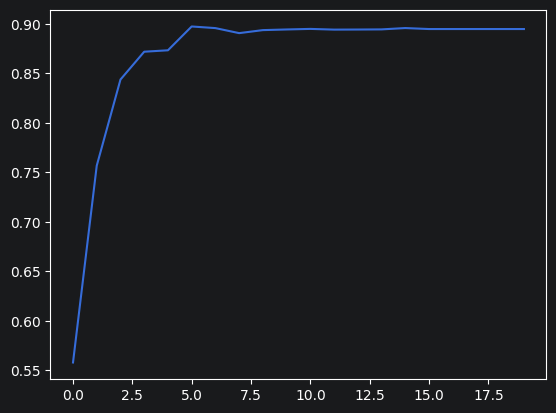

In [104]:
history["SubcategoryMulticlassF1Score"].plot()

<Axes: >

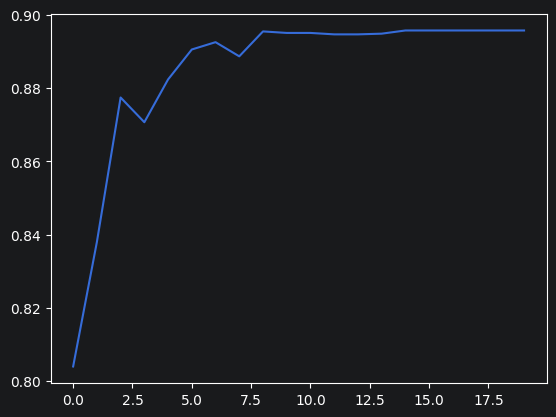

In [103]:
history["CategoryMulticlassF1Score"].plot()

Ниже пример одного объявления, которое я украл с фарпоста. Результат меня устраивает, в подкатегориях победила категория ремонта и строительства, видимо потому что среди меток в датасете не было аналога. Еще ниже можно увидеть пример без картинки, только текст, здесь модель тоже работает хорошо и определяет, что кассовая лента -- это для бизнеса

In [106]:
text = """Title: Мышеловка пластиковая Истребитель с логотипом (100) Зарит
Description: Современное устройство для отлова мышей, отличающееся безопасностью и простотой обслуживания в сочетании с эффективностью его применения. Работа данного изделия управляется всего одной, но достаточно мощной пружиной, охватывающей всю заднюю часть захлопывающегося механизма."""

image_path = "/home/sinus/Downloads/test.jpg"

Title: Мышеловка пластиковая Истребитель с логотипом (100) Зарит
Description: Современное устройство для отлова мышей, отличающееся безопасностью и простотой обслуживания в сочетании с эффективностью его применения. Работа данного изделия управляется всего одной, но достаточно мощной пружиной, охватывающей всю заднюю часть захлопывающегося механизма.
Categories:
87.35% Для дома и дачи
7.74% Для бизнеса
2.35% Хобби и отдых
Subcategories:
79.42% Ремонт и строительство
9.40% Оборудование для бизнеса
3.94% Товары для животных


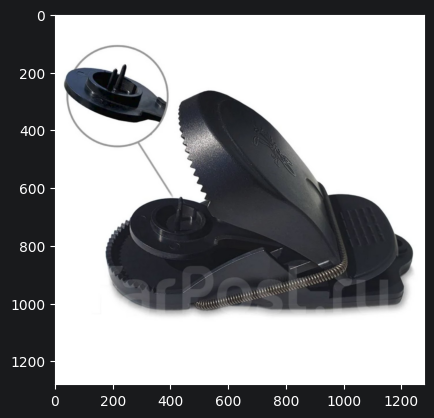

In [110]:
top_cat, top_subcat = get_categories(
    text,
    image_path,
    cat_le.classes_,
    subcat_le.classes_,
    embedder,
    model,
    prompt
)

In [111]:
text = """Title: Чековая лента 80х80/намотка 50метров/
Description: Продажа оптом и в розницу чековой ленты любых размеров:

Чековая лента 57х40х12 (намот 17м)- 15,00 р.
Чековая лента 80х80х18 (намот 50м)- 71,00 р.

В связи с нестабильностью курса валют просим Вас уточнять актуальные цены и наличие товара у наших менеджеров."""

In [112]:
top_cat, top_subcat = get_categories(
    text,
    None,
    cat_le.classes_,
    subcat_le.classes_,
    embedder,
    model,
    prompt
)

Title: Чековая лента 80х80/намотка 50метров/
Description: Продажа оптом и в розницу чековой ленты любых размеров:

Чековая лента 57х40х12 (намот 17м)- 15,00 р.
Чековая лента 80х80х18 (намот 50м)- 71,00 р.

В связи с нестабильностью курса валют просим Вас уточнять актуальные цены и наличие товара у наших менеджеров.
Categories:
98.64% Для бизнеса
0.92% Для дома и дачи
0.22% Хобби и отдых
Subcategories:
87.38% Оборудование для бизнеса
7.82% Готовый бизнес
1.90% Оргтехника и расходники


Я думаю, что если еще поиграться с обучением, моделями, гиперпараметрами, датасетом и его чисткой и так далее и так далее, то получится добрать точность до 95%